In [2]:
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
from matplotlib import colors
import numpy as np
import os,re
import math

In [3]:
# import plotting packages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

from mpl_toolkits.mplot3d import Axes3D # 3d plot
from matplotlib import cm #color map
from matplotlib.ticker import FormatStrFormatter # set decimals in ticks
from matplotlib import rc,re
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator

font=12
fontfml='Times New Roman'
plt.rcParams['font.size'] = font
plt.rcParams['font.family'] = fontfml
plt.rcParams['mathtext.fontset']='custom'
plt.rcParams['mathtext.rm'] =fontfml
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
#plt.legend(loc="best",ncol=1,columnspacing=0.5,handlelength=1,handletextpad=0.3)

from LBL_funcs_fullSpectrum import *
from LBL_funcs_plotting import *
from LBL_funcs_inclined import *

In [4]:
file_dir = "/mnt/dengnan/RTM/fullspectrum/HG/"
Fls = ['Results_case2_AOD=0.1243_COD=0_kap=[10, 11, 12]_th0=18_Ta=297_RH=0.43.npy']

In [5]:
results = np.load(file_dir +'/'+Fls[0],  allow_pickle=True).item()
dnu = 3# speactral resolution 0.1 is enough, 0.01 is too fine, especially for cloudy periods
nu=np.arange(2500,35000,dnu) 
F_uw = results.get('F_uw')
np.trapz(F_uw,nu)

202.4425076825995

In [6]:
results.keys()

dict_keys(['F_dw', 'F_uw', 'F_dni', 'F_dhi'])

# broadband, COD, theta, 

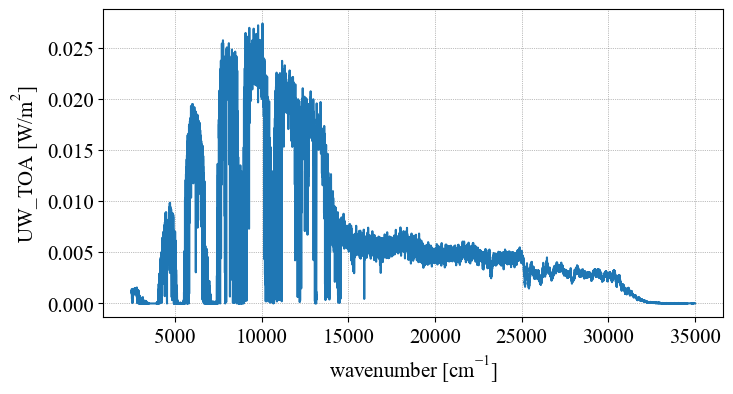

In [7]:
font=15
fontfml='Times New Roman'
plt.rcParams['font.size'] = font
plt.rcParams['font.family'] = fontfml
plt.rcParams['mathtext.fontset']='custom'
plt.rcParams['mathtext.rm'] =fontfml
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(8, 4))
gs1 = gridspec.GridSpec(1, 1) 
gs1.update(wspace=0.07, hspace=0.10)
axs = fig.add_subplot(gs1[0])
GHI = []

axs.plot(nu,F_uw)
#axs.set_title('$T_s$ = 290 K')
axs.set_xlabel(r"wavenumber [cm$^{-1}$]")

axs.set_ylabel(r"UW_TOA [W/m$^2$]")
axs.grid(color='grey', linestyle=':', linewidth=0.5)
fig_dir = "./"
# Uncomment the next line to save the figure
#fig.savefig(fig_dir + 'Zenith_COD_UW_toa.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
from fun_nearealtime_RTM import FY4A_calinu,get_calibration_srf

In [9]:
data = np.genfromtxt('./data/profiles/ASTMG173.csv', delimiter=',', skip_header=2,  # in wavenumber basis
                     names=['wavelength', 'extraterrestrial', '37tilt', 'direct_circum'])
ref_lam = data['wavelength']  # nm avoid hearder 1
ref_E = data['extraterrestrial']
ref_E_nu = -ref_E * ref_lam ** 2 / 1e7  # W/[m2*nm-1] tp W/[m2*cm-1]
F_dw_os = -np.interp(-nu, -1e7 / ref_lam, ref_E_nu)  # W/[m2*cm-1] to W/cm-1

0.04021668983166893
0.06272402285404269
0.07642646843580524
0.0790702489857163
0.003851481965692024
0.0003578007087298873


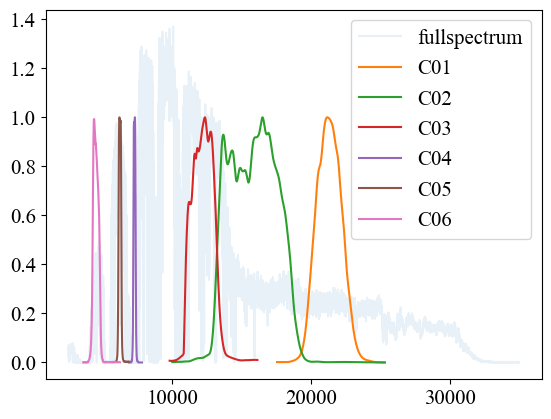

In [37]:
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
nu0 = np.arange(2500, 35000, 3)  # Wavenumber grid
nu_channels = FY4A_calinu(nu0, channels, "./FY4A_data/", dnu=3)
F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                       12.06884597258561,13.936208329862962,18.20438461023419]
uw = F_uw
plt.plot(nu,F_uw*50, alpha=0.1, label='fullspectrum')
for i, channel in enumerate(channels):
    # load calibration data : Spectral Response Func
    srf, nu_channel = get_calibration_srf(channel, file_dir)
    nu_idx = np.nonzero(np.isin(nu_channels, nu_channel))[0]  # fixed 1 April.
    uw_cor = np.multiply(uw[nu_idx], srf)
    #uw_cor = uw[nu_idx]
    uw_channel = np.trapz(uw_cor, nu_channel)/F_dw_os_srf_channel[i]
    
    ref_channel = uw_channel/np.pi
    plt.plot(nu_channel,srf, label=f'{channel}')
    
    print(ref_channel)
    
plt.legend(loc ='upper right')
plt.show()

0.04021668983166893
0.06272402285404269
0.07642646843580524
0.0790702489857163
0.003851481965692024
0.0003578007087298873


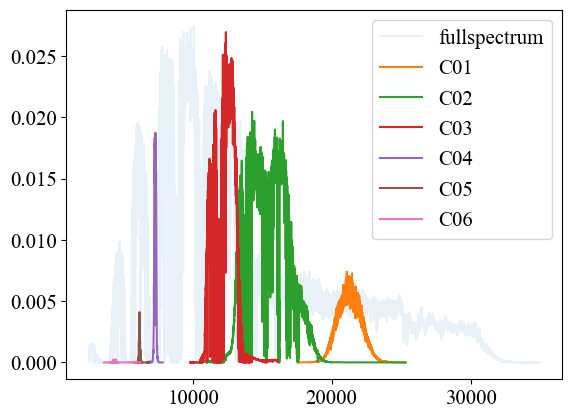

In [47]:
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
nu0 = np.arange(2500, 35000, 3)  # Wavenumber grid
nu_channels = FY4A_calinu(nu0, channels, "./FY4A_data/", dnu=3)
F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                       12.06884597258561,13.936208329862962,18.20438461023419]
uw = F_uw
plt.plot(nu,F_uw, alpha=0.1, label='fullspectrum')
for i, channel in enumerate(channels):
    # load calibration data : Spectral Response Func
    srf, nu_channel = get_calibration_srf(channel, file_dir)
    nu_idx = np.nonzero(np.isin(nu_channels, nu_channel))[0]  # fixed 1 April.
    uw_cor = np.multiply(uw[nu_idx], srf)
    uw_channel = np.trapz(uw_cor, nu_channel)/F_dw_os_srf_channel[i]
    ref_channel = uw_channel/np.pi
    print(ref_channel)
    plt.plot(nu_channel,uw_cor, label=f'{channel}')

plt.legend(loc ='upper right')
plt.show()

In [32]:
channel = 'C01'
nu = np.arange(2500, 35000, 3)
sensor = 'FY4A'
channel_number = int(channel[-2:])
dirpath = './' + 'FY4A_data/AGRI_calibration/'
channel_srf = os.path.join(dirpath,'FY4A_AGRI_SRF_ch{:d}.txt'.format(channel_number))
calibration = np.loadtxt(channel_srf, delimiter=',', skiprows=1)
calibration_nu = calibration[:, 1]
calibration_srf = calibration[:, 2]
nu_channel = FY4A_calinu(nu, [channel], file_dir, dnu=3)
calibration_nu = calibration_nu[::-1]
calibration_srf = calibration_srf[::-1]
srf = np.interp(nu_channel, calibration_nu, calibration_srf)
print(channel,nu_channel[0],nu_channel[-1])

C01 17545 25315


In [ ]:
0.3,0.3,0.3,0.02,0.3,0.2

In [10]:
results2 = np.load(file_dir +'/'+Fls2[-1],  allow_pickle=True).item()
Fdw1=results2.get('F_uw')[1,:]
Fls2

array(['Results_case2_RH=0.0_Tsurf=290_AOD=0.0_COD=10.0_kap=[8, 9, 10]_th0=0.npy',
       'Results_case2_RH=0.0_Tsurf=290_AOD=0.0_COD=10.0_kap=[8, 9, 10]_th0=15.npy',
       'Results_case2_RH=0.0_Tsurf=290_AOD=0.0_COD=10.0_kap=[8, 9, 10]_th0=30.npy',
       'Results_case2_RH=0.0_Tsurf=290_AOD=0.0_COD=10.0_kap=[8, 9, 10]_th0=45.npy',
       'Results_case2_RH=0.0_Tsurf=290_AOD=0.0_COD=10.0_kap=[8, 9, 10]_th0=60.npy',
       'Results_case2_RH=0.0_Tsurf=290_AOD=0.0_COD=10.0_kap=[8, 9, 10]_th0=75.npy'],
      dtype='<U73')

In [11]:
COD = []
theta = []
for string in Fls2:
    match = re.search(r'COD=([\d.]+)_', string)
    if match:
        number = float(match.group(1))
        COD.append(number)
    match = re.search(r'th0=([\d.]+).npy', string)
    if match:
        number = float(match.group(1))
        theta.append(number)

In [12]:
theta

[0.0, 15.0, 30.0, 45.0, 60.0, 75.0]

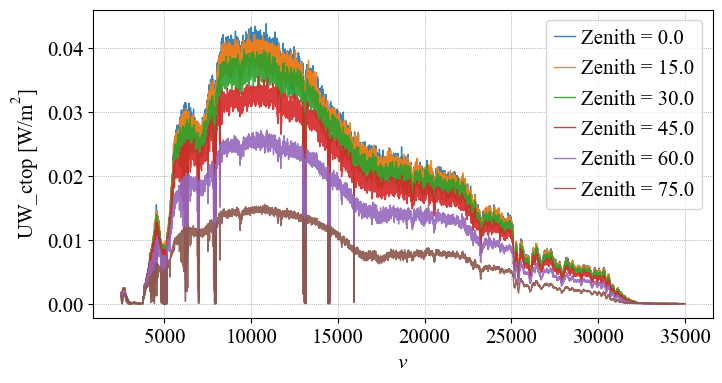

In [13]:
#items = [0,1,2,6,5,4,3]
UW_sum=[]
fig = plt.figure(figsize=(8,4))
gs1 = gridspec.GridSpec(1, 1) 
gs1.update(wspace=0.1, hspace=0.15)
ax1 = fig.add_subplot(gs1[0])
#ax2 = fig.add_subplot(gs1[1])
for i in range(len(Fls2)):
    results = np.load(file_dir +'/'+Fls2[i],  allow_pickle=True).item()
    Fuw_ctop=results.get('F_uw')[-1,:]
    ax1.plot(nu, Fuw_ctop, label=f'Zenith = {theta[i]}',linewidth=1,alpha=0.9)
    UW_sum.append(np.trapz(Fuw_ctop,nu))

ax1.set_xlabel(r"$\nu$")

ax1.set_ylabel(r"UW_ctop [W/m$^2$]")
ax1.grid(color='grey', linestyle=':', linewidth=0.5)

ax1.legend(loc='upper right', ncol=1, columnspacing=0.5,handlelength=1,handletextpad=0.3)

plt.show()
#fig.savefig('COD_UW_ctop_spectrum.png', dpi=300, bbox_inches='tight')